<a href="https://colab.research.google.com/github/Dkaushani/Policy-Market-Analytics/blob/main/Consumer_Analytics_Segmentation_kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Step 2: Set Kaggle Token and download the E-Commerce dataset
import os

# 1. Set the environment variable with your specific token
# (Make sure to keep the single quotes around the token)
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_de2d8ae5dfec007f3a5ef397b22176db'

# 2. Download the dataset directly from Kaggle
!kaggle datasets download -d carrie1/ecommerce-data

# 3. Unzip the downloaded file (-o overwrites it if you run this twice)
!unzip -o ecommerce-data.zip

print("Dataset downloaded and unzipped successfully!")

Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data
License(s): unknown
100% 7.20M/7.20M [00:00<00:00, 250MB/s]

Archive:  ecommerce-data.zip
  inflating: data.csv                
Dataset downloaded and unzipped successfully!


In [5]:
# Step 3: Load libraries and clean the data
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Read the CSV (using ISO-8859-1 encoding which is common for older retail databases)
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

# 1. Drop rows where CustomerID is missing
df = df.dropna(subset=['CustomerID'])

# 2. Keep only valid transactions (Quantity > 0)
df = df[df['Quantity'] > 0]

# 3. Create a 'TotalSpend' column (Quantity * UnitPrice)
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

# 4. Convert 'InvoiceDate' from text to a proper Python datetime object
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Data cleaned! We have {len(df)} valid transactions.")
df.head()

Data cleaned! We have 397924 valid transactions.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [6]:
# Step 4: Build the RFM Table

# Set our "today" date to one day after the last transaction in the dataset
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by CustomerID
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency (count unique invoices)
    'TotalSpend': 'sum'                                      # Monetary
})

# Rename columns so they are easy to read
rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [7]:
# Step 5: Standardize and Cluster

# Standardize the data so all variables have equal weight
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Run K-Means to find 3 distinct customer groups
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# View the average characteristics of each cluster
cluster_means = rfm.groupby('Cluster').mean().round(1)
print("--- Average Metrics per Cluster ---")
print(cluster_means)

# Assign readable names based on typical retail patterns
segment_map = {
    0: 'Standard/Recent',
    1: 'Inactive/Low Spend',
    2: 'Whales/High Value'
}
rfm['Segment'] = rfm['Cluster'].map(segment_map)

--- Average Metrics per Cluster ---
         Recency  Frequency  Monetary
Cluster                              
0           41.4        4.7    1855.4
1          247.1        1.6     631.4
2            6.0       66.5   85904.4


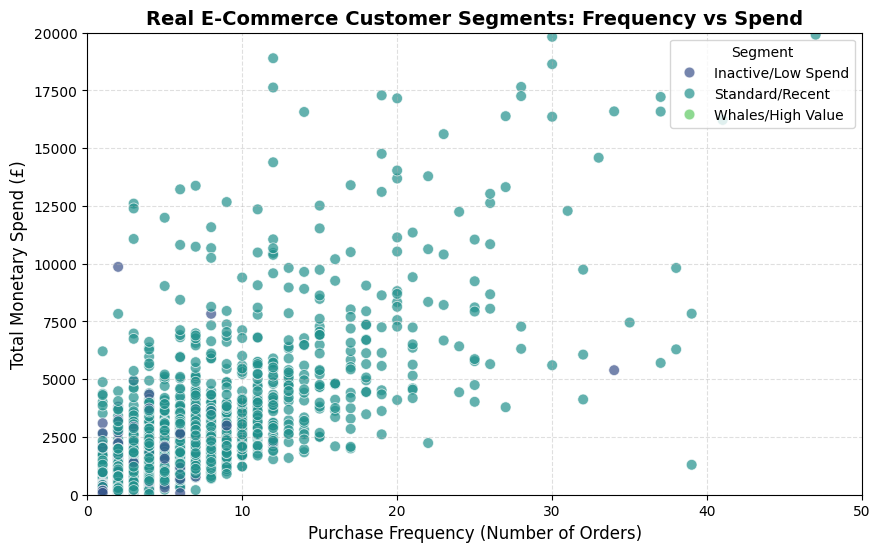

In [8]:
# Step 6: Plot the Customer Segments
plt.figure(figsize=(10, 6))

# Create a scatter plot comparing Frequency vs Monetary spend
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    palette='viridis',
    s=60,
    alpha=0.7
)

# Formatting for a professional look
plt.title('Real E-Commerce Customer Segments: Frequency vs Spend', fontsize=14, fontweight='bold')
plt.xlabel('Purchase Frequency (Number of Orders)', fontsize=12)
plt.ylabel('Total Monetary Spend (£)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)

# Limit axes slightly to zoom in on the main cluster of data (ignoring extreme outliers)
plt.xlim(0, 50)
plt.ylim(0, 20000)

plt.show()

--- Cleaned Data Cluster Averages ---
         Recency  Frequency  Monetary
Cluster                              
0          253.1        1.4     405.1
1           32.4        7.1    2780.2
2           51.2        2.3     686.8


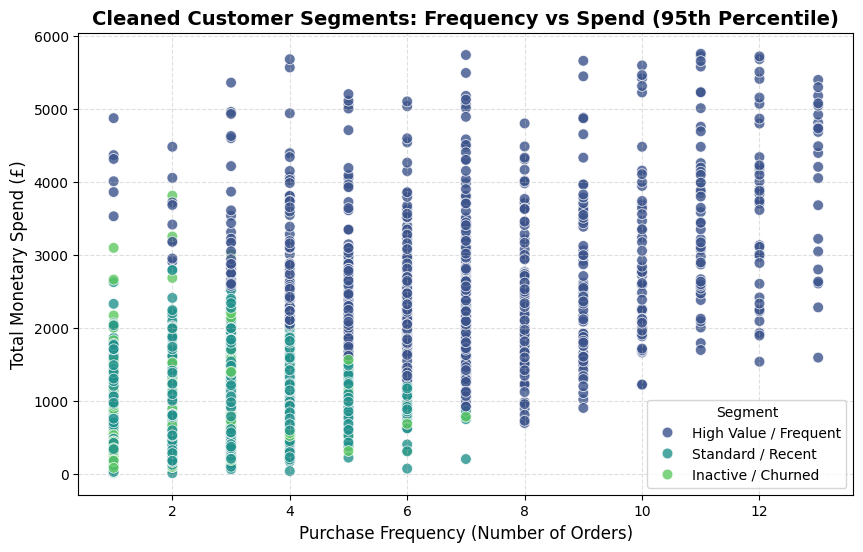

In [9]:
# --- REVISED STEP 5 & 6: Outlier Filtering & Clustering ---

# 1. Filter out the top 5% extreme outliers to prevent algorithm skew
q_spend = rfm['Monetary'].quantile(0.95)
q_freq = rfm['Frequency'].quantile(0.95)

# Create a clean dataframe without the extreme wholesalers
rfm_clean = rfm[(rfm['Monetary'] <= q_spend) & (rfm['Frequency'] <= q_freq)].copy()

# 2. Standardize the cleaned data
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_clean[['Recency', 'Frequency', 'Monetary']])

# 3. Run K-Means again
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm_clean['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 4. View the new averages to understand our new groups
# FIX: Only select numeric columns to calculate the mean
print("--- Cleaned Data Cluster Averages ---")
print(rfm_clean.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1))

# Dynamically map the segments based on Recency
sorted_clusters = rfm_clean.groupby('Cluster')['Recency'].mean().sort_values().index
segment_map = {
    sorted_clusters[0]: 'High Value / Frequent',
    sorted_clusters[1]: 'Standard / Recent',
    sorted_clusters[2]: 'Inactive / Churned'
}
rfm_clean['Segment'] = rfm_clean['Cluster'].map(segment_map)

# 5. Plot the cleaned data
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rfm_clean,
    x='Frequency',
    y='Monetary',
    hue='Segment',
    palette='viridis',
    s=60,
    alpha=0.8
)

plt.title('Cleaned Customer Segments: Frequency vs Spend (95th Percentile)', fontsize=14, fontweight='bold')
plt.xlabel('Purchase Frequency (Number of Orders)', fontsize=12)
plt.ylabel('Total Monetary Spend (£)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [10]:
# --- STEP 7: Interactive 3D Visualization ---
import plotly.express as px

# 1. Create a 3D scatter plot mapping all three RFM dimensions
fig = px.scatter_3d(
    rfm_clean,
    x='Recency',         # X-axis: Days since last order
    y='Frequency',       # Y-axis: Number of orders
    z='Monetary',        # Z-axis: Total spend
    color='Segment',     # Color dots by their assigned cluster
    color_discrete_map={
        'High Value / Frequent': '#2c728e', # Deep Blue
        'Standard / Recent': '#20a486',     # Teal
        'Inactive / Churned': '#7ad151'     # Light Green
    },
    opacity=0.75,        # Make dots slightly transparent to see density
    title='<b>3D Customer Segmentation: Recency, Frequency, and Monetary Value</b>'
)

# 2. Adjust marker size and layout for a professional appearance
fig.update_traces(marker=dict(size=4))
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    scene=dict(
        xaxis_title='Recency (Days)',
        yaxis_title='Frequency (Orders)',
        zaxis_title='Monetary (£)'
    ),
    template='plotly_white'
)

# 3. Render the interactive plot
fig.show()